# Прогнозирование качества вин

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn

from matplotlib import pyplot as plt
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from tensorflow.keras.layers import Conv2D, Flatten, Dense, AvgPool2D, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Sequential

## Загрузка и предварительная обработка данных

Загрузим датасет с сайта (если не получится, можно скачать 2 файла: отдельно с красными и отдельно с белыми винами, добавить цвет как признак и объединить в 1 датасет).

In [ ]:
try:
    df = pd.read_csv('https://archive.ics.uci.edu/static/public/186/data.csv', sep=',')
except:
    df1 = pd.read_csv('winequality-red.csv', sep=';')
    df1['color'] = 'red'
    df2 = pd.read_csv('winequality-white.csv', sep=';')
    df2['color'] = 'white'
    df = pd.concat([df1, df2], ignore_index=True)

Описание данных:
- `fixed acidity`: фиксированная кислотность
- `volatile acidity`: летучая кислотность
- `citric acid`: лимонная кислота
- `residual sugar`: остаточный сахар
- `chlorides`: хлориды
- `free sulfur dioxide`: свободный диоксид серы
- `total sulfur dioxide`: общий диоксид серы
- `density`: плотность
- `pH`: pH
- `sulphates`: сульфаты
- `alcohol`: спирт
- `quality`: прогнозируемое качество вина от 1 до 10
- `color`: цвет вина (красное или белое)

In [ ]:
def dfinfo(df):
    df.info()
    display(df.head())
    print('Пропуски:')
    print(df.isna().sum())
    print('Дубликатов', df.duplicated().sum())

dfinfo(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  color                 6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


Пропуски:
fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
color                   0
dtype: int64
Дубликатов 1177


У нас 6497 строк в датасете, все признаки, кроме цвета, числовые. Пропусков нет, есть 1177 дубликатов. Одинаковые образцы вин не несут ценности для обучения модели, поэтому дубликаты можно удалить.

In [ ]:
df = df.drop_duplicates()
df.duplicated().sum()

0

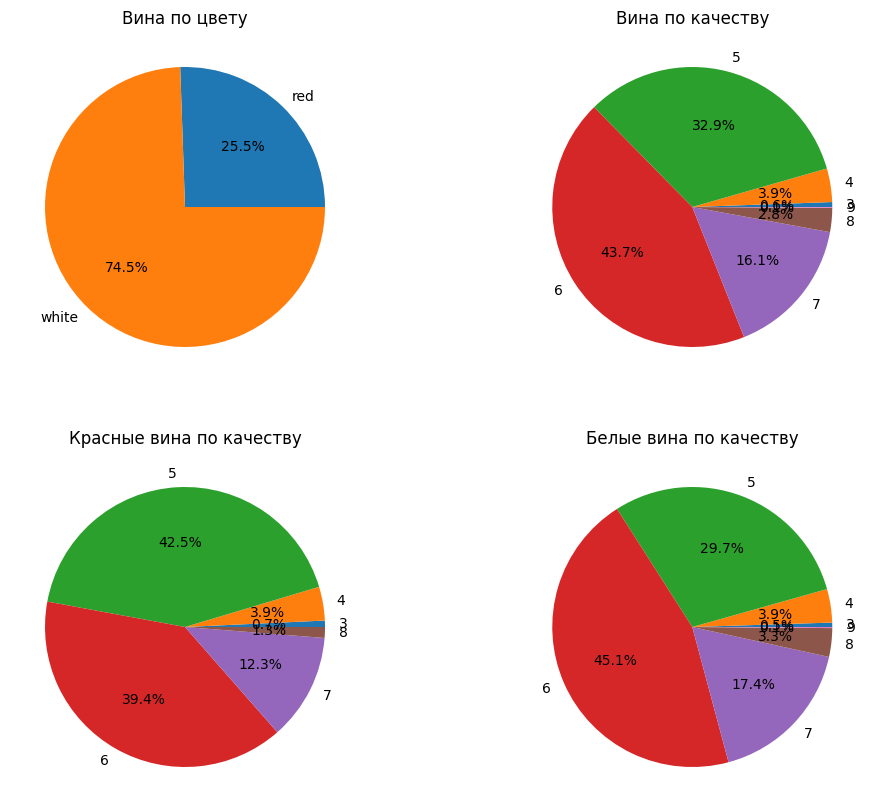

In [ ]:
fig,axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
df.pivot_table(index='color', aggfunc='count').plot(kind='pie', y='pH', autopct='%1.1f%%', ylabel='', legend=False, title='Вина по цвету', ax=axes[0][0])
df.pivot_table(index='quality', aggfunc='count').plot(kind='pie', y='pH', autopct='%1.1f%%', ylabel='', legend=False, title='Вина по качеству', ax=axes[0][1])
df.query('color=="red"').pivot_table(index='quality', aggfunc='count').plot(kind='pie', y='pH', autopct='%1.1f%%', ylabel='', legend=False,
                                                                            title='Красные вина по качеству', ax=axes[1][0])
df.query('color=="white"').pivot_table(index='quality', aggfunc='count').plot(kind='pie', y='pH', autopct='%1.1f%%', ylabel='', legend=False,
                                                                              title='Белые вина по качеству', ax=axes[1][1]);

In [ ]:
df['quality'].value_counts()

,count
quality,
6,2323
5,1752
7,856
4,206
8,148
3,30
9,5


In [ ]:
df[df['quality']==9]

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color
2373,9.1,0.27,0.45,10.6,0.035,28.0,124.0,0.99700,3.20,0.46,10.4,9,white
2419,6.6,0.36,0.29,1.6,0.021,24.0,85.0,0.98965,3.41,0.61,12.4,9,white
2426,7.4,0.24,0.36,2.0,0.031,27.0,139.0,0.99055,3.28,0.48,12.5,9,white
2475,6.9,0.36,0.34,4.2,0.018,57.0,119.0,0.98980,3.28,0.36,12.7,9,white
3204,7.1,0.26,0.49,2.2,0.032,31.0,113.0,0.99030,3.37,0.42,12.9,9,white


У нас около четверти красных вин в датасете, остальные белые. Очень мало вин с оценками качества 3-4 и 8-9. Большинство красных на 5, белых на 6 баллов. Нет красных с качеством 9 (а белых таких только 5 образцов).

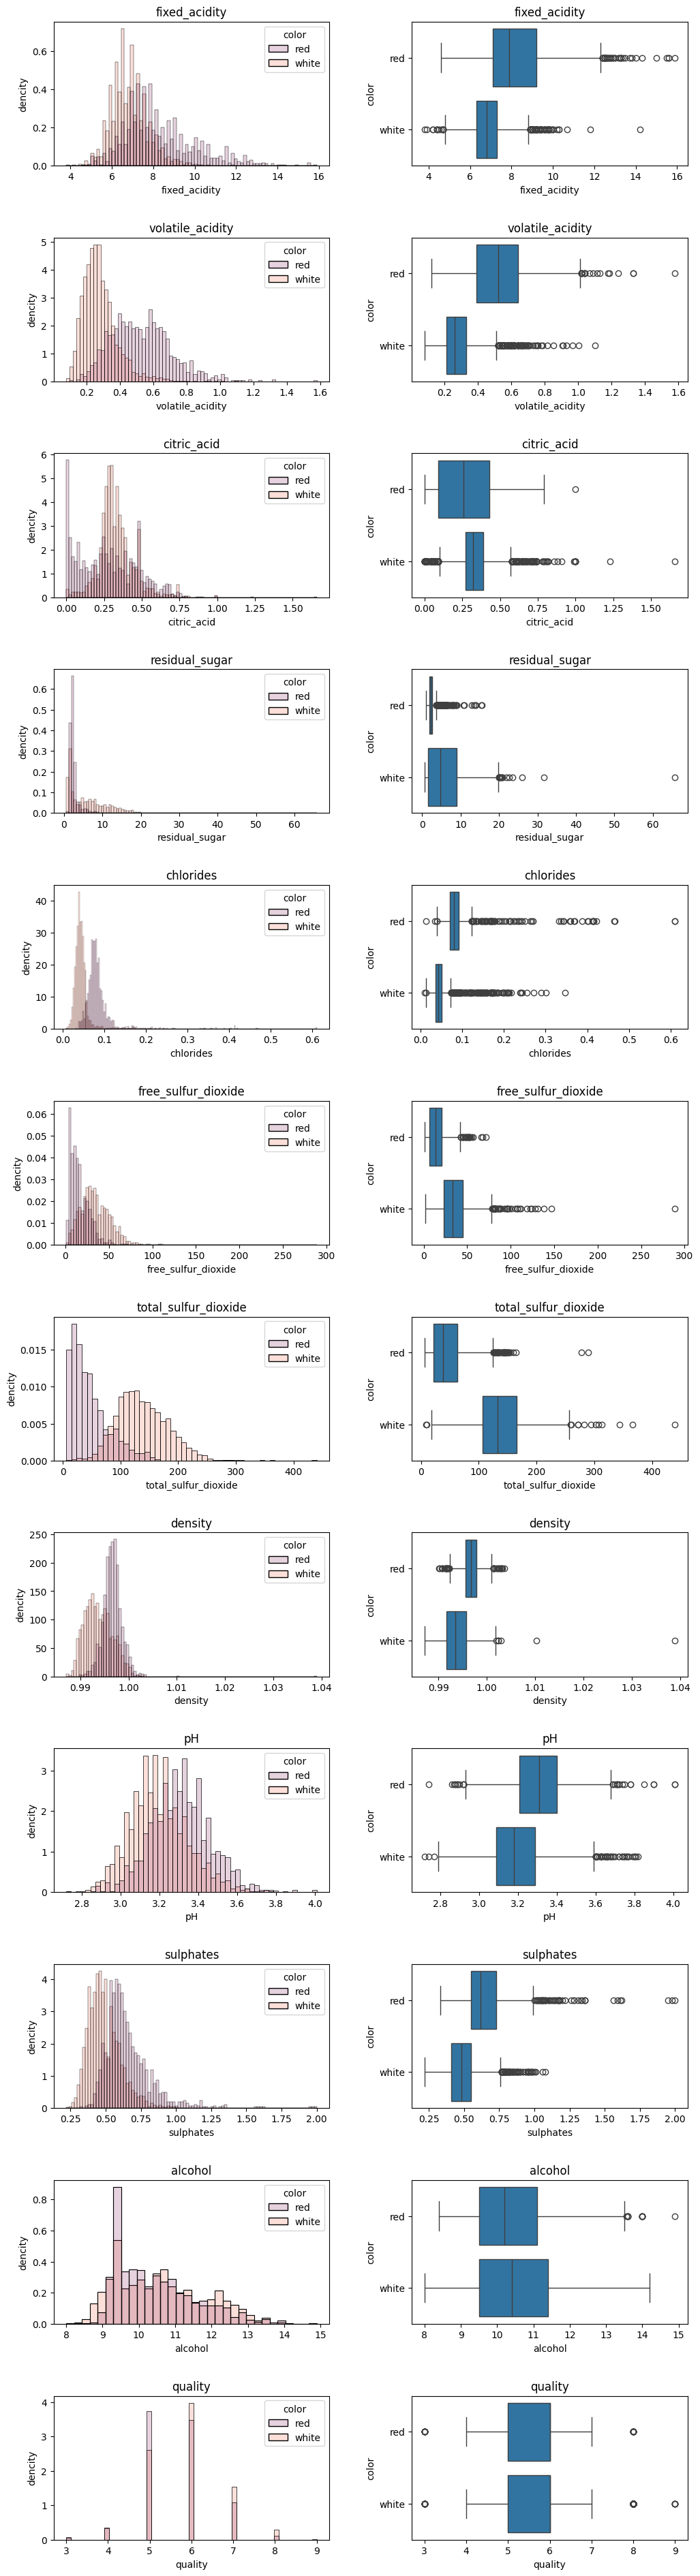

In [ ]:
def eda_num(df):
  list_col = df.select_dtypes(exclude='object').columns
  fig,axes = plt.subplots(nrows=len(list_col), ncols=2, figsize=(12, len(list_col)*4), gridspec_kw={'hspace': 0.5, 'wspace': 0.3})
  i=0
  for col in list_col:
    sns.histplot(stat='density', common_norm=False, data=df, x=col, hue='color', ax=axes[i][0], alpha=0.2, palette='rocket').set(title=col, ylabel='dencity')
    sns.boxplot(x=col, y='color', data=df, ax=axes[i][1]).set(title=col)
    i+=1
  plt.show()

eda_num(df)

Посмотрим распределения показателей состава вин (в разрезе по цвету). Выбросами  будем считать только дальние, сильно выбивающиеся из остального распределения, чтобы не удалить реальные, но не распространённые показатели.

- лимонная кислота выше 1.2
- остаточный сахар выше 30
- хлориды выше 0.3
- свободный диоксид серы выше 150
- общий диоксид серы выше 300
- плотность выше 1.01
- сульфаты выше 1,5

Такие выбросы удаляем.

In [ ]:
df = df[df['citric_acid']<1.2]
df = df[df['residual_sugar']<30]
df = df[df['chlorides']<0.3]
df = df[df['free_sulfur_dioxide']<150]
df = df[df['total_sulfur_dioxide']<300]
df = df[df['density']<1.01]
df = df[df['sulphates']<1.5]

После удаления выбросов распределения ближе к нормальному.

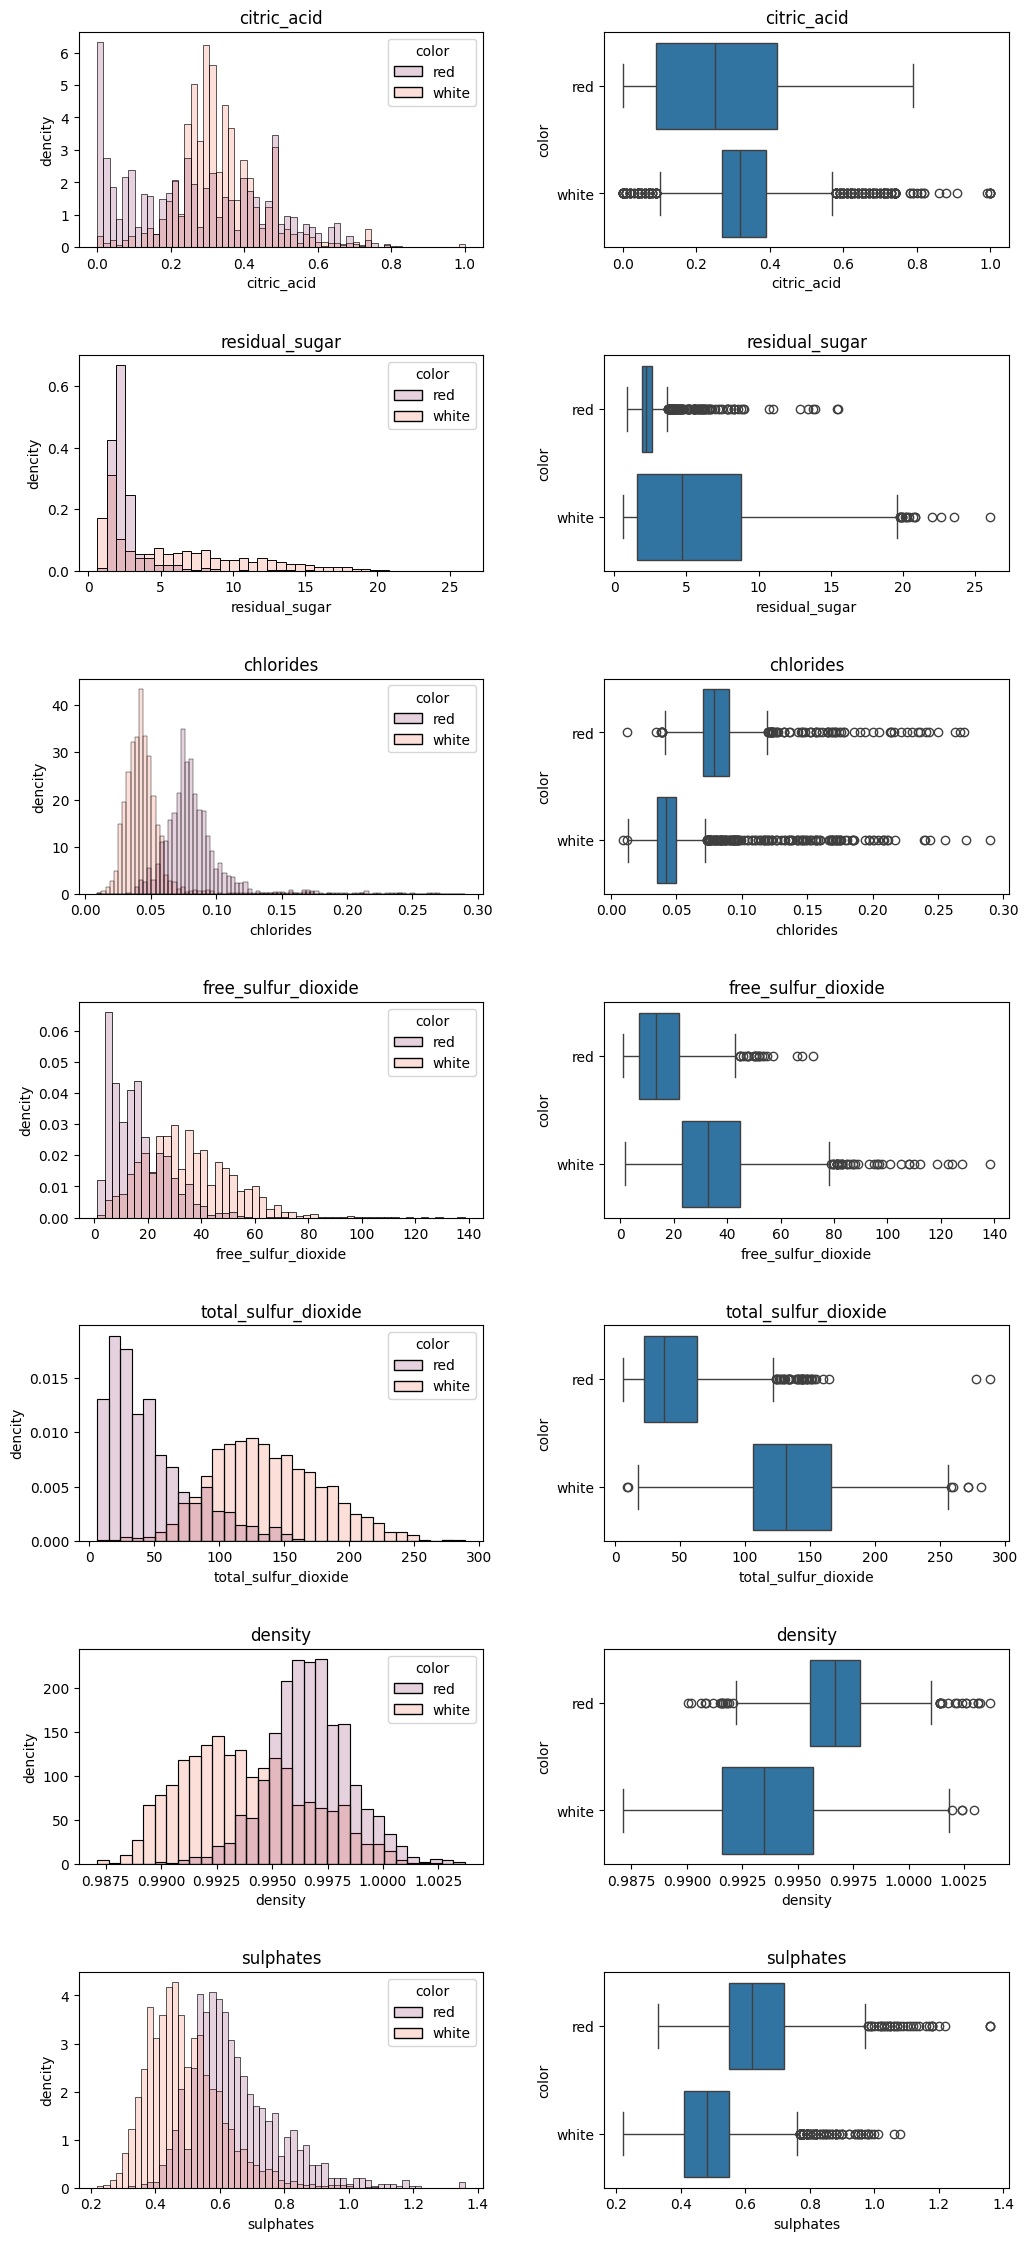

In [ ]:
eda_num(df[['citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'sulphates', 'color']])

Делим на тренировочную и тестовую выборки (целевой признак - качество, задача регрессии). В препроцессоре применим энкодер для нормализации числовых признаков и кодировки категориального (цвет).

In [ ]:
RANDOM_STATE = 42
TEST_SIZE = 0.25

X = df.drop(['quality'], axis=1)
y = df['quality']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = TEST_SIZE, random_state = RANDOM_STATE)

In [ ]:
data_preprocessor = ColumnTransformer(
    [
        ('num', MinMaxScaler(), X.select_dtypes(exclude='object').columns),
        ('ohe', OneHotEncoder(drop='first'), X.select_dtypes(include='object').columns),

    ],
    remainder='passthrough') # verbose_feature_names_out=False)

In [ ]:
X_train_proc = data_preprocessor.fit_transform(X_train)
X_test_proc = data_preprocessor.transform(X_test)

## Разработка модели

Обучим полносвязную нейронную сеть в 1 слой.
Метрики - MAE и R2.
Функция потерь - MSE.
Функция активации - ReLU.
Оптимизатор - SGD (стохастический градиентный спуск, ускоряющий обучение модели за счёт разделения выборки на батчи и вычисления градиента по батчам, т.е. частями).

In [ ]:
model = Sequential()
model.add(Dense(units=1, input_dim=X_train.shape[1], activation='relu'))

model.compile(loss='mean_squared_error', optimizer='sgd', metrics=['r2_score', 'mae'])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.fit(X_train_proc, y_train,
          epochs=50, verbose=2,
          shuffle=True,
          validation_data=(X_test_proc, y_test))

Epoch 1/50
124/124 - 1s - 12ms/step - loss: 3.2208 - mae: 1.3058 - r2_score: -3.1654e+00 - val_loss: 0.9304 - val_mae: 0.7707 - val_r2_score: -2.1686e-01
Epoch 2/50
124/124 - 0s - 2ms/step - loss: 0.8482 - mae: 0.7236 - r2_score: -9.6916e-02 - val_loss: 0.7968 - val_mae: 0.7083 - val_r2_score: -4.2112e-02
Epoch 3/50
124/124 - 0s - 2ms/step - loss: 0.7476 - mae: 0.6735 - r2_score: 0.0332 - val_loss: 0.7384 - val_mae: 0.6781 - val_r2_score: 0.0342
Epoch 4/50
124/124 - 0s - 2ms/step - loss: 0.6970 - mae: 0.6490 - r2_score: 0.0985 - val_loss: 0.6962 - val_mae: 0.6543 - val_r2_score: 0.0894
Epoch 5/50
124/124 - 0s - 3ms/step - loss: 0.6684 - mae: 0.6345 - r2_score: 0.1355 - val_loss: 0.6825 - val_mae: 0.6469 - val_r2_score: 0.1074
Epoch 6/50
124/124 - 0s - 3ms/step - loss: 0.6511 - mae: 0.6264 - r2_score: 0.1579 - val_loss: 0.6640 - val_mae: 0.6363 - val_r2_score: 0.1315
Epoch 7/50
124/124 - 0s - 2ms/step - loss: 0.6383 - mae: 0.6198 - r2_score: 0.1744 - val_loss: 0.6535 - val_mae: 0.6302 -

In [ ]:
y_pred = model.predict(X_test_proc)
print('Метрика MAE на тестовой выборке:', round(mean_absolute_error(y_test, y_pred), 4))
print('Метрика R2 на тестовой выборке:', round(r2_score(y_test, y_pred), 4))

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Метрика MAE на тестовой выборке: 0.5887
Метрика R2 на тестовой выборке: 0.2477


Мы получили MAE 0.5887, т.е. модель предсказывает качество с ошибкой в среднем чуть больше полбалла (это неплохо).

R2 = 0.2477, это намного меньше единицы (идеальной метрики), но число хотя бы положительное, т.е. модель предсказывает лучше, чем "угадывание" среднего значения по выборке.

(Практика показала, что добавление слоёв в модель, смена функции активации, подбор размера батча только ухудшают результат, например, R2 становится отрицательным. Увеличение количества эпох тоже не улучшает результат.)

In [ ]:
y_pred = [y_pred[i][0] for i in range(len(y_pred))]

## Визуализация результатов работы модели

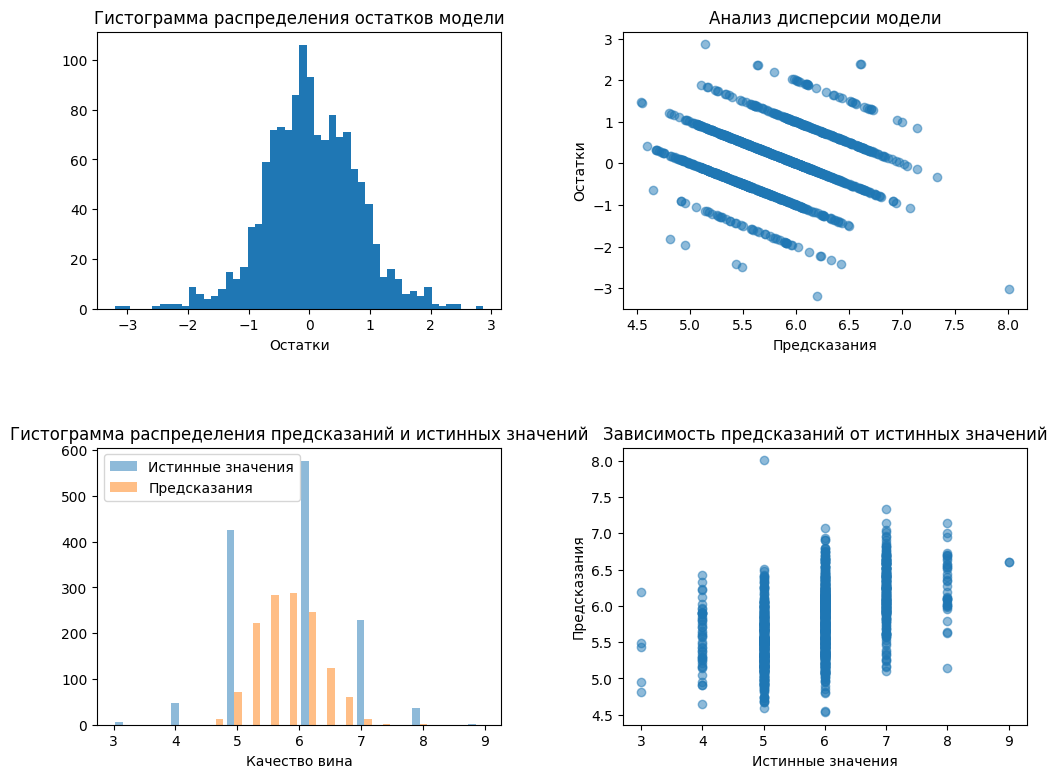

In [ ]:
residuals = y_test - y_pred

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12,9), gridspec_kw={'hspace': 0.5, 'wspace': 0.3})
axes[0][0].hist(residuals, bins=50)
axes[0][0].set_title('Гистограмма распределения остатков модели')
axes[0][0].set_xlabel('Остатки')

axes[0][1].scatter(x=y_pred, y=residuals, alpha=0.5)
axes[0][1].set_xlabel('Предсказания')
axes[0][1].set_ylabel('Остатки')
axes[0][1].set_title('Анализ дисперсии модели')

axes[1][0].hist([y_test, y_pred], alpha=0.5, bins=20)
axes[1][0].set_xlabel('Качество вина')
axes[1][0].set_title('Гистограмма распределения предсказаний и истинных значений')
axes[1][0].legend(['Истинные значения', 'Предсказания'])

axes[1][1].scatter(x=y_test, y=y_pred, alpha=0.5)
axes[1][1].set_xlabel('Истинные значения')
axes[1][1].set_ylabel('Предсказания')
axes[1][1].set_title('Зависимость предсказаний от истинных значений');

In [ ]:
print('Предсказания', min(y_pred), '-', max(y_pred), ', истинные значения', min(y_test), '-', max(y_test))

Предсказания 4.536559 - 8.009745 , истинные значения 3 - 9


Качество большинства образцов модель предсказывает правильно (остатки, т.е. ошибки модели нормально распределены вокруг нуля). Проблемы с предсказанием качества 3-4 и 8-9, т.е. образцов которых в датасете было очень мало. Модель не научилась предсказывать слабо представленные варианты (3, 4 и 9 не предсказала ни разу), лучше всего предсказывает 6 (среднее значение, оно же самое распространённое в выборке).

Для улучшения модели можно добавить в обучающий датасет образцы с качеством 3-4 и 8-9.

Если такой возможности нет, можно попробовать:
- обучить обычную линейную регрессию с подбором гиперпараметров,
- вместо задачи регрессии решить задачу мультиклассовой классификации с несбалансированными классами (тогда нужны будут другие метрики, например, f1-макро).